In [92]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_context("talk")

In [93]:
BASE = Path("..")
if not (BASE / "processed_data").exists():
    # fallback if notebook is run from repo root
    BASE = Path(".")

PROCESSED = BASE / "processed_data"
RAW = BASE / "raw_data"

crime_weather_path = PROCESSED / "merged_weather_crime_districts_data.csv"
socio_path = RAW / "socio_economic_data_2010.csv"
econ_path = RAW / "economic_data.csv"

## Refactor notes

This version keeps **all rendered visualization cells** from the original notebook, while trimming non-essential notebook noise:
- removed one-off debug / inspection cells
- removed commented-out dead code
- kept the full trend and relationship visualizations
- kept the original rendered outputs for the plotting cells

The analysis logic and story remain intact, but the notebook is easier to read.

In [94]:
def normalize_colname(col):
    col = str(col)
    col = col.strip()
    col = col.replace("\xa0", " ")
    col = re.sub(r"\s+", " ", col)
    return col

def clean_columns(df):
    out = df.copy()
    out.columns = [normalize_colname(c) for c in out.columns]
    return out

def first_existing(df, candidates, default=None):
    normalized = {c.lower(): c for c in df.columns}
    for cand in candidates:
        key = cand.lower()
        if key in normalized:
            return normalized[key]
    return default

def parse_district_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = re.search(r"(\d+)", s)
    return float(m.group(1)) if m else np.nan

def safe_numeric(series):
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
        .replace({"nan": np.nan, "None": np.nan, "": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )
    
def clean_us_number(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("'", "", regex=False)
        .str.replace('"', "", regex=False)
        .str.strip(),
        errors="coerce"
    )

def summarize_missing(df, top_n=20):
    miss = df.isna().mean().sort_values(ascending=False)
    return (miss[miss > 0].head(top_n) * 100).round(2)

def add_time_features(df, date_col):
    df = df.copy()
    df["year"] = df[date_col].dt.year
    df["month"] = df[date_col].dt.month
    df["quarter"] = df[date_col].dt.quarter
    df["day_of_week"] = df[date_col].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    return df

In [95]:
crime_weather = pd.read_csv(crime_weather_path)
crime_weather = clean_columns(crime_weather)

print("Shape:", crime_weather.shape)
print("Columns:")
print(list(crime_weather.columns))
crime_weather.head()

Shape: (2119451, 17)
Columns:
['ID', 'DATE RPTD', 'CRIME', 'VICT AGE', 'VICT SEX', 'VICT DESCENT', 'PLACE', 'LAT', 'LON', 'DATETIME OCC', 'WEAPON CATEGORY', 'TEMPERATURE', 'PERCIPITATION', 'WIND SPEED', 'RAIN', 'SNOWFALL', 'DISTRICT']


,ID,DATE RPTD,CRIME,VICT AGE,VICT SEX,VICT DESCENT,PLACE,LAT,LON,DATETIME OCC,WEAPON CATEGORY,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT
0,1307355,2010-02-20,VIOLATION OF COURT ORDER,48,M,H,SINGLE FAMILY DWELLING,33.9825,-118.2695,2010-02-20 13:00:00,No Weapon,14.2,0.0,9.7,0.0,0.0,9
1,11401303,2010-09-13,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",Unknown,M,W,STREET,33.9599,-118.3962,2010-09-12 00:00:00,No Weapon,16.5,0.0,4.1,0.0,0.0,11
2,70309629,2010-08-09,OTHER MISCELLANEOUS CRIME,Unknown,M,H,ALLEY,34.0224,-118.2524,2010-08-09 15:00:00,No Weapon,25.5,0.0,11.5,0.0,0.0,9
3,90631215,2010-01-05,VIOLATION OF COURT ORDER,47,F,W,STREET,34.1016,-118.3295,2010-01-05 01:00:00,Firearm,8.1,0.0,7.4,0.0,0.0,13
4,100100501,2010-01-03,"RAPE, ATTEMPTED",47,F,H,ALLEY,34.0387,-118.2488,2010-01-02 21:00:00,Strong-Arm,11.6,0.0,8.5,0.0,0.0,14


In [96]:
district_col = first_existing(
    crime_weather,
    [
        "district", "District", "COUNCIL DISTRICT", "Council District",
        "council_district", "district_id", "CD", "cd"
    ],
)

datetime_col = first_existing(
    crime_weather,
    [
        "DATETIME OCC", "datetime occ", "datetime", "DATE OCC", "DATE RPTD", "date"
    ],
)

crime_col = first_existing(crime_weather, ["CRIME", "crime", "Crm Cd Desc", "crime_type"])
temp_col = first_existing(crime_weather, ["TEMPERATURE", "temperature", "temp"])
rain_col = first_existing(crime_weather, ["RAIN", "rain", "PRECIPITATION", "PERCIPITATION"])
wind_col = first_existing(crime_weather, ["WIND SPEED", "wind speed", "wind_speed"])
snow_col = first_existing(crime_weather, ["SNOWFALL", "snowfall"])

print("Detected district column:", district_col)
print("Detected datetime column:", datetime_col)
print("Detected crime column:", crime_col)
print("Detected weather columns:", temp_col, rain_col, wind_col, snow_col)

Detected district column: DISTRICT
Detected datetime column: DATETIME OCC
Detected crime column: CRIME
Detected weather columns: TEMPERATURE RAIN WIND SPEED SNOWFALL


In [97]:
if datetime_col is None:
    raise ValueError("No date/datetime column detected in merged crime-weather dataset.")

cw = crime_weather.copy()

cw[datetime_col] = pd.to_datetime(cw[datetime_col], errors="coerce")
if district_col is None:
    raise ValueError("No district column detected. Add/rename a district field before continuing.")

cw[district_col] = cw[district_col].apply(parse_district_value).astype("Int64")

for c in [temp_col, rain_col, wind_col, snow_col]:
    if c is not None:
        cw[c] = pd.to_numeric(cw[c], errors="coerce")

cw["date"] = cw[datetime_col].dt.floor("D")
cw = cw.dropna(subset=["date", district_col]).copy()

print("Rows after cleaning:", len(cw))
cw[[district_col, "date"] + [c for c in [crime_col, temp_col, rain_col, wind_col, snow_col] if c is not None]].head()

Rows after cleaning: 2119451


,DISTRICT,date,CRIME,TEMPERATURE,RAIN,WIND SPEED,SNOWFALL
0,9,2010-02-20,VIOLATION OF COURT ORDER,14.2,0.0,9.7,0.0
1,11,2010-09-12,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",16.5,0.0,4.1,0.0
2,9,2010-08-09,OTHER MISCELLANEOUS CRIME,25.5,0.0,11.5,0.0
3,13,2010-01-05,VIOLATION OF COURT ORDER,8.1,0.0,7.4,0.0
4,14,2010-01-02,"RAPE, ATTEMPTED",11.6,0.0,8.5,0.0


## 3. Build the district-day panel

This is the central analytical dataset.

In [98]:
agg_dict = {}
if crime_col is not None:
    agg_dict[crime_col] = "count"

for c in [temp_col, wind_col]:
    if c is not None:
        agg_dict[c] = "mean"

for c in [rain_col, snow_col]:
    if c is not None:
        agg_dict[c] = "sum"

panel = (
    cw.groupby([district_col, "date"], as_index=False)
      .agg(agg_dict)
      .rename(columns={
          district_col: "district",
          crime_col: "crime_count" if crime_col is not None else "crime_count",
          temp_col: "temperature_mean" if temp_col is not None else temp_col,
          wind_col: "wind_speed_mean" if wind_col is not None else wind_col,
          rain_col: "rain_total" if rain_col is not None else rain_col,
          snow_col: "snow_total" if snow_col is not None else snow_col,
      })
)

panel = add_time_features(panel, "date")
panel = panel.sort_values(["district", "date"]).reset_index(drop=True)

print("District-day panel shape:", panel.shape)
panel.head()

District-day panel shape: (54780, 12)


,district,date,crime_count,temperature_mean,wind_speed_mean,rain_total,snow_total,year,month,quarter,day_of_week,is_weekend
0,1,2010-01-01,150,11.924667,6.198000,0.0,0.0,2010,1,1,4,0
1,1,2010-01-02,29,16.689655,6.544828,0.0,0.0,2010,1,1,5,1
2,1,2010-01-03,23,14.952174,7.860870,0.0,0.0,2010,1,1,6,1
3,1,2010-01-04,20,13.895000,6.975000,0.0,0.0,2010,1,1,0,0
4,1,2010-01-05,20,14.990000,5.475000,0.0,0.0,2010,1,1,1,0


## 4. Load and clean the socio-economic data

Your `socio_economic_data_2010.csv` looks like district-level static census-style information.  
That is very useful for explaining **cross-district differences** in crime, but remember:

- it is **static**
- it should be interpreted as a structural background characteristic
- it should not be over-claimed as a year-by-year causal driver

In [100]:
# Try multiple encodings - the CSV has special characters and unnamed index
socio = None
for encoding in ['utf-8-sig', 'utf-8', 'latin-1', 'iso-8859-1', 'cp1252']:
    try:
        socio = pd.read_csv(socio_path, encoding=encoding, index_col=0)
        print(f"✓ Successfully read socioeconomic file with encoding: {encoding}")
        break
    except (UnicodeDecodeError, Exception):
        continue

if socio is None:
    socio = pd.read_csv(socio_path, index_col=0)  # Fallback

socio = socio.reset_index(drop=False)  # Convert index to column
socio = clean_columns(socio)

print("\nSocio shape:", socio.shape)
print("Socio columns (first 20):")
print(list(socio.columns[:20]))
print("\nFirst 2 rows:")
socio.head(2)

✓ Successfully read socioeconomic file with encoding: utf-8-sig

Socio shape: (15, 41)
Socio columns (first 20):
['Council District', 'Pop2010', 'White_pop', 'Black_pop', 'Ameri_es_pop', 'Asian_pop', 'Hawn_pi_pop', 'Hispanic_pop', 'Other_pop', 'Multi_pop', 'Male_pop', 'Female_pop', 'Age_under5Ê', 'Age_5_9', 'Age_10_14', 'Age_15_19', 'Age_20_24', 'Age_25_34', 'Age_35_44', 'Age_45_54']

First 2 rows:


,Council District,Pop2010,White_pop,Black_pop,Ameri_es_pop,Asian_pop,Hawn_pi_pop,Hispanic_pop,Other_pop,Multi_pop,Male_pop,Female_pop,Age_under5Ê,Age_5_9,Age_10_14,Age_15_19,Age_20_24,Age_25_34,Age_35_44,Age_45_54,Age_55_64,Age_65_74,Age_75_84,Age_85_up,Median_age,Med_age_male,Med_age_female,Households,Avg_hh_size,HouseholdsHsehld_1_m,Hsehld_1_f,Marhh_chd,Marhh_no_c,Mhh_child,Fhh_child,Families,Avg_family_size,Housing_units,Vacant,Owner_occ,Renter_occ
0,1 - Gilbert Cedillo,"245,216.22","90,857","7,759.13","2,991.73","43,397.31",243.41,"172,971.55","88,016.11","11,951.53","125,733.82","119,482.4","17,684.82","15,825.97","16,274.35","18,528.22","22,124.94","43,690.39","36,967.18","29,490.28","21,779.51","12,261.12","7,507.17","3,082.27",23.8,23.23,24.46,"79,014.81",2.29,"9,919.21","9,326.98","17,472.38","12,582.79","3,923.03","8,697.64","51,391.85",2.68,"85,219.33","6,204.52","15,219.58","63,795.23"
1,10 - Herb J. Wesson Jr.,"261,297.85","68,458.12","67,087.07","2,307.88","43,148.34",308.11,"126,872.43","68,188.27","11,800.07","127,383.22","133,914.63","17,464.54","15,872.99","16,002.86","17,760.48","20,202.21","45,774.95","40,715.42","35,563.92","25,890.49","14,316.31","8,077.55","3,656.14",26.7,25.47,27.80,"95,915.92",2.05,"13,147.03","16,341.94","17,301.48","14,284.08","3,736.82","10,927.24","57,677.78",2.52,"103,637.46","7,721.54","21,764.3","74,151.62"


In [102]:
socio_district_col = first_existing(
    socio,
    ["Council District", "council_district", "district", "CD #", "CD#", "CD"]
)

if socio_district_col is None:
    raise ValueError("Could not detect district column in socioeconomic data.")

socio = socio.copy()
socio["district"] = socio[socio_district_col].apply(parse_district_value).astype("Int64")

# Convert likely numeric columns - they have comma-formatted numbers like "245,216.22"
print("Converting columns to numeric...")
converted_count = 0
for col in socio.columns:
    if col == "district":
        continue
    
    # Try to convert
    original_dtype = socio[col].dtype
    socio[col] = clean_us_number(socio[col])
    
    # Check if conversion worked
    non_null_after = socio[col].notna().sum()
    if non_null_after > 0:
        print(f"  ✓ {col}: {non_null_after} non-null values")
        converted_count += 1
    else:
        print(f"  ✗ {col}: all NaN (may be text)")

print(f"\nSuccessfully converted {converted_count} columns")

# Keep numeric columns + district
socio_numeric_cols = ["district"] + [
    c for c in socio.columns
    if c != "district" and pd.api.types.is_numeric_dtype(socio[c])
]
socio_clean = socio[socio_numeric_cols].copy()

print("\nSocio cleaned shape:", socio_clean.shape)
print("Numeric columns:", len(socio_numeric_cols))
socio_clean.head()

Converting columns to numeric...
  ✗ Council District: all NaN (may be text)
  ✓ Pop2010: 15 non-null values
  ✓ White_pop: 15 non-null values
  ✓ Black_pop: 15 non-null values
  ✓ Ameri_es_pop: 15 non-null values
  ✓ Asian_pop: 15 non-null values
  ✓ Hawn_pi_pop: 15 non-null values
  ✓ Hispanic_pop: 15 non-null values
  ✓ Other_pop: 15 non-null values
  ✓ Multi_pop: 15 non-null values
  ✓ Male_pop: 15 non-null values
  ✓ Female_pop: 15 non-null values
  ✓ Age_under5Ê: 15 non-null values
  ✓ Age_5_9: 15 non-null values
  ✓ Age_10_14: 15 non-null values
  ✓ Age_15_19: 15 non-null values
  ✓ Age_20_24: 15 non-null values
  ✓ Age_25_34: 15 non-null values
  ✓ Age_35_44: 15 non-null values
  ✓ Age_45_54: 15 non-null values
  ✓ Age_55_64: 15 non-null values
  ✓ Age_65_74: 15 non-null values
  ✓ Age_75_84: 15 non-null values
  ✓ Age_85_up: 15 non-null values
  ✓ Median_age: 15 non-null values
  ✓ Med_age_male: 15 non-null values
  ✓ Med_age_female: 15 non-null values
  ✓ Households: 15 non-n

,district,Council District,Pop2010,White_pop,Black_pop,Ameri_es_pop,Asian_pop,Hawn_pi_pop,Hispanic_pop,Other_pop,Multi_pop,Male_pop,Female_pop,Age_under5Ê,Age_5_9,Age_10_14,Age_15_19,Age_20_24,Age_25_34,Age_35_44,Age_45_54,Age_55_64,Age_65_74,Age_75_84,Age_85_up,Median_age,Med_age_male,Med_age_female,Households,Avg_hh_size,HouseholdsHsehld_1_m,Hsehld_1_f,Marhh_chd,Marhh_no_c,Mhh_child,Fhh_child,Families,Avg_family_size,Housing_units,Vacant,Owner_occ,Renter_occ
0,1,NaN,245216.22,90857.00,7759.13,2991.73,43397.31,243.41,172971.55,88016.11,11951.53,125733.82,119482.40,17684.82,15825.97,16274.35,18528.22,22124.94,43690.39,36967.18,29490.28,21779.51,12261.12,7507.17,3082.27,23.80,23.23,24.46,79014.81,2.29,9919.21,9326.98,17472.38,12582.79,3923.03,8697.64,51391.85,2.68,85219.33,6204.52,15219.58,63795.23
1,10,NaN,261297.85,68458.12,67087.07,2307.88,43148.34,308.11,126872.43,68188.27,11800.07,127383.22,133914.63,17464.54,15872.99,16002.86,17760.48,20202.21,45774.95,40715.42,35563.92,25890.49,14316.31,8077.55,3656.14,26.70,25.47,27.80,95915.92,2.05,13147.03,16341.94,17301.48,14284.08,3736.82,10927.24,57677.78,2.52,103637.46,7721.54,21764.30,74151.62
2,11,NaN,250726.93,174020.70,13569.60,1214.43,30132.14,521.02,47243.32,18894.80,12374.24,122850.80,127876.13,12912.21,10819.57,10293.89,12293.09,18079.32,47888.78,41225.72,34581.38,29208.43,17584.13,10585.69,5254.73,28.67,28.41,28.99,113864.22,1.61,19434.85,22484.17,17305.63,24708.30,1874.20,4632.45,55447.15,2.07,123048.13,9183.91,50753.74,63110.49
3,12,NaN,258715.95,158939.64,11239.45,1193.56,46815.27,374.43,70827.63,27943.83,12209.77,126366.09,132349.86,12795.71,14149.84,16409.15,20221.50,19350.71,30225.42,34815.25,40495.71,33019.38,19200.82,12678.59,5353.88,33.28,32.21,34.14,86732.07,2.44,7206.04,9337.50,22493.92,26040.98,2137.22,5223.44,63921.59,2.72,90415.80,3683.73,60274.21,26457.86
4,13,NaN,247142.04,113391.23,9109.58,2320.07,43740.54,315.72,133038.67,66020.53,12244.39,126882.12,120259.92,13604.88,12094.61,13019.49,15804.39,21508.48,50084.22,40330.45,32614.28,23706.25,13312.35,8003.20,3059.46,25.73,25.20,26.39,94906.83,1.93,17101.47,15325.45,15096.73,14479.35,3100.50,7569.90,49457.04,2.48,102632.78,7725.95,13638.56,81268.27


In [103]:
# Create a smaller interpretable feature block if these variables exist
preferred_socio = [
    "Pop2010", "Median_age", "Households", "Avg_hh_size",
    "Owner_occ", "Renter_occ", "White_pop", "Black_pop", "Hispanic_pop", "Asian_pop",
    "Male_pop", "Female_pop"
]

available_socio = [c for c in preferred_socio if c in socio_clean.columns]
if not available_socio:
    available_socio = [c for c in socio_clean.columns if c != "district"][:15]

socio_model = socio_clean[["district"] + available_socio].copy()
print("Selected socioeconomic columns:")
print(available_socio)
socio_model.head()

Selected socioeconomic columns:
['Pop2010', 'Median_age', 'Households', 'Avg_hh_size', 'Owner_occ', 'Renter_occ', 'White_pop', 'Black_pop', 'Hispanic_pop', 'Asian_pop', 'Male_pop', 'Female_pop']


,district,Pop2010,Median_age,Households,Avg_hh_size,Owner_occ,Renter_occ,White_pop,Black_pop,Hispanic_pop,Asian_pop,Male_pop,Female_pop
0,1,245216.22,23.80,79014.81,2.29,15219.58,63795.23,90857.00,7759.13,172971.55,43397.31,125733.82,119482.40
1,10,261297.85,26.70,95915.92,2.05,21764.30,74151.62,68458.12,67087.07,126872.43,43148.34,127383.22,133914.63
2,11,250726.93,28.67,113864.22,1.61,50753.74,63110.49,174020.70,13569.60,47243.32,30132.14,122850.80,127876.13
3,12,258715.95,33.28,86732.07,2.44,60274.21,26457.86,158939.64,11239.45,70827.63,46815.27,126366.09,132349.86
4,13,247142.04,25.73,94906.83,1.93,13638.56,81268.27,113391.23,9109.58,133038.67,43740.54,126882.12,120259.92


In [104]:
# Helpful derived rates if the ingredients exist
if {"Pop2010", "Owner_occ", "Renter_occ"}.issubset(socio_model.columns):
    housing_total = socio_model["Owner_occ"].fillna(0) + socio_model["Renter_occ"].fillna(0)
    socio_model["renter_share"] = np.where(housing_total > 0, socio_model["Renter_occ"] / housing_total, np.nan)
    socio_model["owner_share"] = np.where(housing_total > 0, socio_model["Owner_occ"] / housing_total, np.nan)

if {"Pop2010", "Male_pop", "Female_pop"}.issubset(socio_model.columns):
    socio_model["sex_ratio_male"] = np.where(
        socio_model["Female_pop"] > 0,
        socio_model["Male_pop"] / socio_model["Female_pop"],
        np.nan
    )

socio_model.head()

,district,Pop2010,Median_age,Households,Avg_hh_size,Owner_occ,Renter_occ,White_pop,Black_pop,Hispanic_pop,Asian_pop,Male_pop,Female_pop,renter_share,owner_share,sex_ratio_male
0,1,245216.22,23.80,79014.81,2.29,15219.58,63795.23,90857.00,7759.13,172971.55,43397.31,125733.82,119482.40,0.807383,0.192617,1.052321
1,10,261297.85,26.70,95915.92,2.05,21764.30,74151.62,68458.12,67087.07,126872.43,43148.34,127383.22,133914.63,0.773090,0.226910,0.951227
2,11,250726.93,28.67,113864.22,1.61,50753.74,63110.49,174020.70,13569.60,47243.32,30132.14,122850.80,127876.13,0.554261,0.445739,0.960702
3,12,258715.95,33.28,86732.07,2.44,60274.21,26457.86,158939.64,11239.45,70827.63,46815.27,126366.09,132349.86,0.305053,0.694947,0.954788
4,13,247142.04,25.73,94906.83,1.93,13638.56,81268.27,113391.23,9109.58,133038.67,43740.54,126882.12,120259.92,0.856295,0.143705,1.055066


## 5. Load and reshape the economic data

Your `economic_data.csv` appears to be a **long-format district economic panel**, with fields like:
- `category`
- `indicator`
- `sub_indicator`
- `council_district`
- `quarter_start`
- `value`

That is good for time-varying district controls, but it needs to be pivoted to a wide format.

In [105]:
econ = pd.read_csv(econ_path)
econ = clean_columns(econ)

print("Economic shape:", econ.shape)
print("Economic columns:")
print(list(econ.columns))
econ.head()

Economic shape: (30752, 18)
Economic columns:
['category', 'indicator', 'sub_indicator', 'locality', 'gender', 'council_district', 'fiscal_year', 'fy_qtr', 'calendar_year', 'cy_qtr', 'quarter_start', 'as_of_date', 'unit_of_measure', 'unit_text', 'value', 'source', 'CD #', 'Proportions']


,category,indicator,sub_indicator,locality,gender,council_district,fiscal_year,fy_qtr,calendar_year,cy_qtr,quarter_start,as_of_date,unit_of_measure,unit_text,value,source,CD #,Proportions
0,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2004-03,2004.0,2004-01,01/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"1,311,096.5",City Of Los Angeles Department Of Building And...,1.0,NaN
1,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2004-04,2004.0,2004-02,04/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"3,081,184.9",City Of Los Angeles Department Of Building And...,1.0,NaN
2,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2005-01,2005.0,2004-03,07/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"4,150,152.8",City Of Los Angeles Department Of Building And...,1.0,NaN
3,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2004,2005-02,2005.0,2004-04,10/01/2004,05/08/2015,$,Seasonally Adjusted And Smoothed,"1,288,147.1",City Of Los Angeles Department Of Building And...,1.0,NaN
4,Building Permits,Multi-family Permit Values,NaN,Los Angeles City,All,1,2005,2005-03,2005.0,2005-01,01/01/2005,05/08/2015,$,Seasonally Adjusted And Smoothed,"1,971,990.6",City Of Los Angeles Department Of Building And...,1.0,NaN


In [106]:
econ_district_col = first_existing(
    econ,
    ["council_district", "Council District", "district", "CD #", "CD"]
)
econ_date_col = first_existing(
    econ,
    ["quarter_start", "quarter start", "as_of_date", "quarter", "date"]
)
value_col = first_existing(econ, ["value", "Value"])
category_col = first_existing(econ, ["category", "Category"])
indicator_col = first_existing(econ, ["indicator", "Indicator"])
subindicator_col = first_existing(econ, ["sub_indicator", "sub indicator", "Sub Indicator"])

print("Detected:", econ_district_col, econ_date_col, value_col, category_col, indicator_col, subindicator_col)

Detected: council_district quarter_start value category indicator sub_indicator


In [107]:
econ_work = econ.copy()
econ_work["district"] = econ_work[econ_district_col].apply(parse_district_value).astype("Int64")
econ_work["econ_date"] = pd.to_datetime(econ_work[econ_date_col], errors="coerce")
econ_work["value_num"] = safe_numeric(econ_work[value_col])

# Build a compact feature name
parts = []
if category_col is not None:
    parts.append(econ_work[category_col].astype(str))
if indicator_col is not None:
    parts.append(econ_work[indicator_col].astype(str))
if subindicator_col is not None:
    parts.append(econ_work[subindicator_col].astype(str))

if parts:
    feature_series = parts[0]
    for p in parts[1:]:
        feature_series = feature_series + " | " + p
else:
    feature_series = pd.Series("economic_value", index=econ_work.index)

econ_work["feature_name"] = (
    feature_series.str.replace(r"\s+", " ", regex=True)
                 .str.replace(r"[^A-Za-z0-9| _-]", "", regex=True)
                 .str.strip()
)

econ_work = econ_work.dropna(subset=["district", "econ_date", "value_num", "feature_name"]).copy()

print("Economic cleaned rows:", len(econ_work))
econ_work[["district", "econ_date", "feature_name", "value_num"]].head()

Economic cleaned rows: 12120


,district,econ_date,feature_name,value_num
12352,1,2008-01-01,Employment | Employment By Establishment Size ...,16310.4
12353,1,2008-04-01,Employment | Employment By Establishment Size ...,17391.9
12354,1,2008-07-01,Employment | Employment By Establishment Size ...,18326.0
12355,1,2008-10-01,Employment | Employment By Establishment Size ...,17314.5
12356,1,2009-01-01,Employment | Employment By Establishment Size ...,16740.6


In [108]:
# Keep the most usable economic features:
# - good district coverage
# - enough temporal variation
coverage = (
    econ_work.groupby("feature_name")
    .agg(
        n_rows=("value_num", "size"),
        n_districts=("district", "nunique"),
        n_dates=("econ_date", "nunique"),
        std_value=("value_num", "std"),
    )
    .reset_index()
)

coverage = coverage.sort_values(
    ["n_districts", "n_dates", "n_rows", "std_value"],
    ascending=False
)

coverage.head(20)

,feature_name,n_rows,n_districts,n_dates,std_value
35,Employment | Total Employment | Total All Indu...,360,15,24,71222.256282
5,Employment | Employment By Establishment Wage ...,360,15,24,63647.877321
1,Employment | Employment By Establishment Size ...,360,15,24,43758.448816
16,Employment | Employment By Industry | Other Se...,360,15,24,23182.347355
2,Employment | Employment By Establishment Size ...,360,15,24,20380.252239
9,Employment | Employment By Industry | Education,360,15,24,13620.358492
0,Employment | Employment By Establishment Size ...,360,15,24,12563.751718
17,Employment | Employment By Industry | Prof Sci...,360,15,24,10130.671604
11,Employment | Employment By Industry | Health Care,360,15,24,8734.290968
19,Employment | Employment By Industry | Transpor...,360,15,24,8303.989002


In [110]:
econ_small = econ_work[econ_work["feature_name"].isin(SELECTED_ECON_FEATURES)].copy()

econ_wide = (
    econ_small.pivot_table(
        index=["district", "econ_date"],
        columns="feature_name",
        values="value_num",
        aggfunc="mean"
    )
    .reset_index()
)

# Merge by month using backward-looking merge_asof:
# each district-day gets the latest available economic reading on or before that day
econ_wide = econ_wide.sort_values(["district", "econ_date"]).reset_index(drop=True)
econ_wide.head()

feature_name,district,econ_date,Employment | Employment By Establishment Size | 50 To 250 Employees,Employment | Employment By Establishment Size | Greater Than 250 Employees,Employment | Employment By Establishment Size | Less Than 50 Employees,Employment | Employment By Establishment Wage | Greater Than 100000,Employment | Employment By Industry | Education,Employment | Employment By Industry | Financial Activities,Employment | Employment By Industry | Health Care,Employment | Employment By Industry | Leisure And Hospitality,Employment | Employment By Industry | Other Services,Employment | Employment By Industry | Prof Sci Tech And Management,Employment | Employment By Industry | Transportation Warehousing And Utilities,Employment | Total Employment | Total All Industries
0,1,2008-01-01,16310.4,122275.2,27693.3,149636.0,72442.3,5455.6,12601.6,5661.2,21438.7,4305.5,5509.4,150741.7
1,1,2008-04-01,17391.9,136122.6,27842.1,163346.4,113300.9,5196.6,12801.0,5625.5,21747.4,4339.1,5394.9,191352.6
2,1,2008-07-01,18326.0,140462.4,28174.4,166392.6,116344.2,5150.5,13073.4,5749.6,21762.9,4335.8,5628.9,194807.8
3,1,2008-10-01,17314.5,127849.0,28011.0,158549.4,108548.3,5047.9,12994.4,5654.2,20605.1,4063.0,5719.7,184786.7
4,1,2009-01-01,16740.6,117853.7,27391.7,144879.1,71613.9,4845.1,13732.7,5693.7,20794.9,4071.9,5471.8,147619.5


## 6. Merge socio-economic and economic data into the panel

In [111]:
panel_full = panel.merge(socio_model, on="district", how="left")

# merge_asof needs sorting and per-district grouping
left = panel_full.sort_values(["district", "date"]).reset_index(drop=True)
right = econ_wide.sort_values(["district", "econ_date"]).reset_index(drop=True)

merged_parts = []
for district_value, left_chunk in left.groupby("district", dropna=False):
    right_chunk = right[right["district"] == district_value].copy()
    if len(right_chunk) == 0:
        merged_parts.append(left_chunk.copy())
        continue
    merged_chunk = pd.merge_asof(
        left_chunk.sort_values("date"),
        right_chunk.sort_values("econ_date"),
        left_on="date",
        right_on="econ_date",
        direction="backward"
    )
    # merge_asof creates duplicate district columns only if naming differs
    if "district_x" in merged_chunk.columns:
        merged_chunk["district"] = merged_chunk["district_x"]
        merged_chunk = merged_chunk.drop(columns=[c for c in ["district_x", "district_y"] if c in merged_chunk.columns])
    merged_parts.append(merged_chunk)

panel_full = pd.concat(merged_parts, ignore_index=True)
panel_full = panel_full.sort_values(["district", "date"]).reset_index(drop=True)

print("Final panel shape:", panel_full.shape)
panel_full.head()

Final panel shape: (54780, 40)


,date,crime_count,temperature_mean,wind_speed_mean,rain_total,snow_total,year,month,quarter,day_of_week,is_weekend,Pop2010,Median_age,Households,Avg_hh_size,Owner_occ,Renter_occ,White_pop,Black_pop,Hispanic_pop,Asian_pop,Male_pop,Female_pop,renter_share,owner_share,sex_ratio_male,econ_date,Employment | Employment By Establishment Size | 50 To 250 Employees,Employment | Employment By Establishment Size | Greater Than 250 Employees,Employment | Employment By Establishment Size | Less Than 50 Employees,Employment | Employment By Establishment Wage | Greater Than 100000,Employment | Employment By Industry | Education,Employment | Employment By Industry | Financial Activities,Employment | Employment By Industry | Health Care,Employment | Employment By Industry | Leisure And Hospitality,Employment | Employment By Industry | Other Services,Employment | Employment By Industry | Prof Sci Tech And Management,Employment | Employment By Industry | Transportation Warehousing And Utilities,Employment | Total Employment | Total All Industries,district
0,2010-01-01,150,11.924667,6.198000,0.0,0.0,2010,1,1,4,0,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1
1,2010-01-02,29,16.689655,6.544828,0.0,0.0,2010,1,1,5,1,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1
2,2010-01-03,23,14.952174,7.860870,0.0,0.0,2010,1,1,6,1,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1
3,2010-01-04,20,13.895000,6.975000,0.0,0.0,2010,1,1,0,0,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1
4,2010-01-05,20,14.990000,5.475000,0.0,0.0,2010,1,1,1,0,245216.22,23.8,79014.81,2.29,15219.58,63795.23,90857.0,7759.13,172971.55,43397.31,125733.82,119482.4,0.807383,0.192617,1.052321,2010-01-01,22502.2,37456.4,31521.7,71808.7,17072.8,4786.1,13976.8,5143.2,19198.8,3839.7,5507.0,90108.6,1


In [113]:
# Normalize crime by population if available
if "Pop2010" in panel_full.columns:
    panel_full["crime_rate_per_1000"] = np.where(
        panel_full["Pop2010"] > 0,
        panel_full["crime_count"] / panel_full["Pop2010"] * 1000,
        np.nan
    )

panel_full[["district", "date", "crime_count"] + [c for c in ["crime_rate_per_1000"] if c in panel_full.columns]].head()

,district,date,crime_count,crime_rate_per_1000
0,1,2010-01-01,150,0.611705
1,1,2010-01-02,29,0.118263
2,1,2010-01-03,23,0.093795
3,1,2010-01-04,20,0.081561
4,1,2010-01-05,20,0.081561


## 7. Data quality checks

This section is here because the merged structure matters more than the model.

In [124]:
print("Missingness (%):")
display(summarize_missing(panel_full, top_n=30))

print("\nDistricts:", panel_full["district"].nunique())
print("Date range:", panel_full["date"].min(), "to", panel_full["date"].max())
print("Rows:", len(panel_full))

Missingness (%):


Series([], dtype: float64)


Districts: 15
Date range: 2010-01-01 00:00:00 to 2019-12-31 00:00:00
Rows: 54780


In [126]:
# Review whether any district has suspiciously low coverage
coverage_by_district = panel_full.groupby("district").agg(
    n_days=("date", "nunique"),
    total_crimes=("crime_count", "sum")
).sort_values("n_days")

coverage_by_district

,n_days,total_crimes
district,,
1,3652,123989
2,3652,123667
3,3652,124975
4,3652,130456
5,3652,115806
6,3652,133822
7,3652,103004
8,3652,195874
9,3652,173552


## 8. Exploratory plots

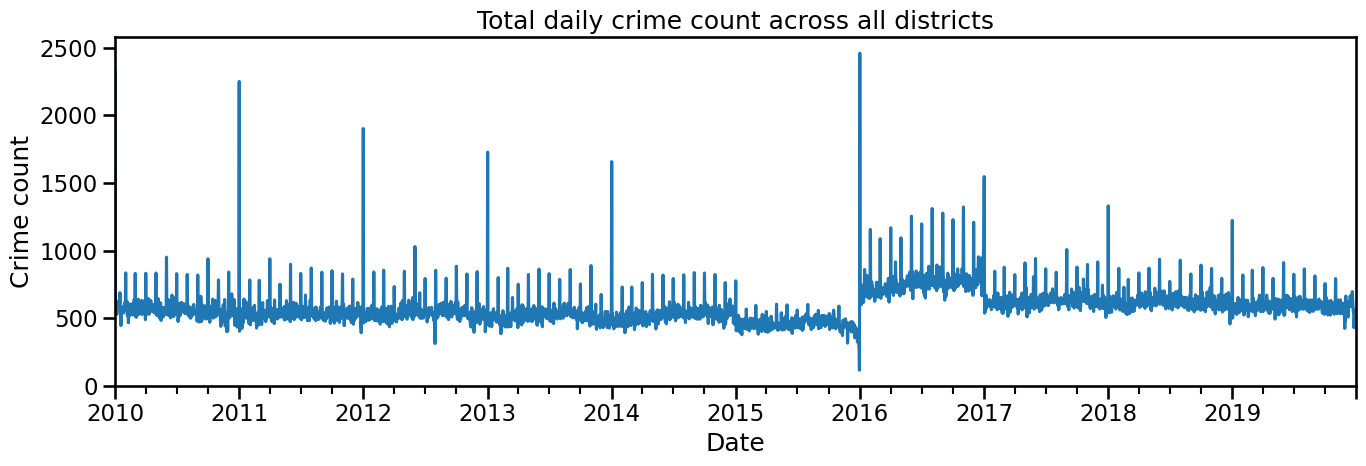

In [118]:
plt.figure(figsize=(14, 5))
panel_full.groupby("date")["crime_count"].sum().plot()
plt.title("Total daily crime count across all districts")
plt.xlabel("Date")
plt.ylabel("Crime count")
plt.tight_layout()
plt.show()

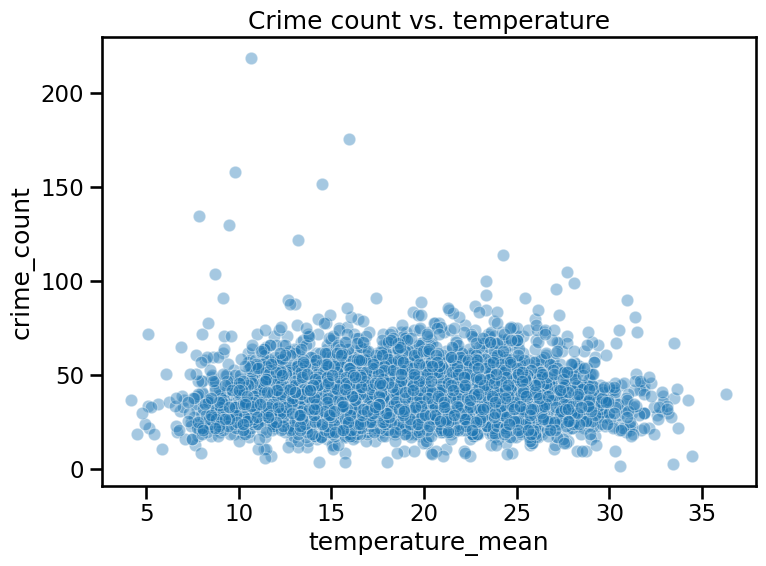

In [119]:
if "temperature_mean" in panel_full.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=panel_full.sample(min(len(panel_full), 5000), random_state=42),
                    x="temperature_mean", y="crime_count", alpha=0.4)
    plt.title("Crime count vs. temperature")
    plt.tight_layout()
    plt.show()

In [127]:
district_summary = (
    panel_full.groupby("district")
    .agg(
        avg_daily_crime=("crime_count", "mean"),
        total_crime=("crime_count", "sum"),
        days=("date", "nunique")
    )
    .reset_index()
)

if "Pop2010" in panel_full.columns:
    pop_by_district = panel_full.groupby("district")["Pop2010"].first().reset_index()
    district_summary = district_summary.merge(pop_by_district, on="district", how="left")
    district_summary["total_crime_per_1000"] = np.where(
        district_summary["Pop2010"] > 0,
        district_summary["total_crime"] / district_summary["Pop2010"] * 1000,
        np.nan
    )

district_summary.head()

,district,avg_daily_crime,total_crime,days,Pop2010,total_crime_per_1000
0,1,33.950986,123989,3652,245216.22,505.631316
1,2,33.862815,123667,3652,256691.84,481.772229
2,3,34.220975,124975,3652,257183.29,485.937481
3,4,35.721796,130456,3652,244117.22,534.399007
4,5,31.710296,115806,3652,252453.38,458.722319


### Weather effect visuals — separated graphs

In [ ]:
# Shared sample for weather relationship charts
panel_sample = panel_full.sample(min(3000, len(panel_full)), random_state=42).copy()
plt.figure(figsize=(8, 6))
plt.scatter(panel_sample["temperature_mean"], panel_sample["crime_count"], alpha=0.3, s=20, color="coral")
z = np.polyfit(panel_sample["temperature_mean"].dropna(),
               panel_sample.loc[panel_sample["temperature_mean"].notna(), "crime_count"], 1)
p = np.poly1d(z)
temp_range = np.linspace(panel_sample["temperature_mean"].min(),
                         panel_sample["temperature_mean"].max(), 100)
plt.plot(temp_range, p(temp_range), "r-", linewidth=2, label="Trend")
plt.xlabel("Temperature (°F)", fontsize=11)
plt.ylabel("Daily Crime Count", fontsize=11)
plt.title("Temperature Effect on Crime", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Shared sample for weather relationship charts
panel_sample = panel_full.sample(min(3000, len(panel_full)), random_state=42).copy()
plt.figure(figsize=(8, 6))
plt.scatter(panel_sample["rain_total"], panel_sample["crime_count"], alpha=0.3, s=20, color="steelblue")
z_rain = np.polyfit(panel_sample["rain_total"].dropna(),
                    panel_sample.loc[panel_sample["rain_total"].notna(), "crime_count"], 1)
p_rain = np.poly1d(z_rain)
rain_range = np.linspace(0, panel_sample["rain_total"].max(), 100)
plt.plot(rain_range, p_rain(rain_range), "b-", linewidth=2, label="Trend")
plt.xlabel("Total Rainfall (inches)", fontsize=11)
plt.ylabel("Daily Crime Count", fontsize=11)
plt.title("Rainfall Effect on Crime", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Shared sample for weather relationship charts
panel_sample = panel_full.sample(min(3000, len(panel_full)), random_state=42).copy()
plt.figure(figsize=(8, 6))
plt.scatter(panel_sample["wind_speed_mean"], panel_sample["crime_count"], alpha=0.3, s=20, color="seagreen")
z_wind = np.polyfit(panel_sample["wind_speed_mean"].dropna(),
                    panel_sample.loc[panel_sample["wind_speed_mean"].notna(), "crime_count"], 1)
p_wind = np.poly1d(z_wind)
wind_range = np.linspace(panel_sample["wind_speed_mean"].min(),
                         panel_sample["wind_speed_mean"].max(), 100)
plt.plot(wind_range, p_wind(wind_range), "g-", linewidth=2, label="Trend")
plt.xlabel("Wind Speed (mph)", fontsize=11)
plt.ylabel("Daily Crime Count", fontsize=11)
plt.title("Wind Speed Effect on Crime", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Socioeconomic effect visuals — separated graphs

In [ ]:
district_data = panel_full.groupby("district").agg({
    "Pop2010": "first",
    "crime_count": "sum"
}).reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(district_data["Pop2010"], district_data["crime_count"], s=200, alpha=0.6, color="purple")
for idx, row in district_data.iterrows():
    plt.annotate(f"D{int(row['district'])}",
                 (row["Pop2010"], row["crime_count"]),
                 fontsize=9, ha="center")
z_pop = np.polyfit(district_data["Pop2010"], district_data["crime_count"], 1)
p_pop = np.poly1d(z_pop)
pop_range = np.linspace(district_data["Pop2010"].min(), district_data["Pop2010"].max(), 100)
plt.plot(pop_range, p_pop(pop_range), "r--", linewidth=2, label="Trend")
plt.xlabel("Population (2010 Census)", fontsize=11)
plt.ylabel("Total Crimes (2010-2019)", fontsize=11)
plt.title("Population vs Total Crime by District", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
district_data2 = panel_full.dropna(subset=["renter_share"]).groupby("district").agg({
    "renter_share": "first",
    "crime_count": "sum"
}).reset_index()

plt.figure(figsize=(8, 6))
plt.scatter(district_data2["renter_share"] * 100, district_data2["crime_count"], s=200, alpha=0.6, color="darkorange")
for idx, row in district_data2.iterrows():
    plt.annotate(f"D{int(row['district'])}",
                 (row["renter_share"] * 100, row["crime_count"]),
                 fontsize=9, ha="center")
z_renter = np.polyfit(district_data2["renter_share"], district_data2["crime_count"], 1)
p_renter = np.poly1d(z_renter)
renter_range = np.linspace(0, 1, 100)
plt.plot(renter_range * 100, p_renter(renter_range), "r--", linewidth=2, label="Trend")
plt.xlabel("Renter-Occupied Share (%)", fontsize=11)
plt.ylabel("Total Crimes", fontsize=11)
plt.title("Housing Type vs Crime", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
if "Median_age" in panel_full.columns:
    district_data3 = panel_full.dropna(subset=["Median_age"]).groupby("district").agg({
        "Median_age": "first",
        "crime_count": "sum"
    }).reset_index()

    plt.figure(figsize=(8, 6))
    plt.scatter(district_data3["Median_age"], district_data3["crime_count"], s=200, alpha=0.6, color="teal")
    for idx, row in district_data3.iterrows():
        plt.annotate(f"D{int(row['district'])}",
                     (row["Median_age"], row["crime_count"]),
                     fontsize=9, ha="center")
    z_age = np.polyfit(district_data3["Median_age"], district_data3["crime_count"], 1)
    p_age = np.poly1d(z_age)
    age_range = np.linspace(district_data3["Median_age"].min(), district_data3["Median_age"].max(), 100)
    plt.plot(age_range, p_age(age_range), "r--", linewidth=2, label="Trend")
    plt.xlabel("Median Age (years)", fontsize=11)
    plt.ylabel("Total Crimes", fontsize=11)
    plt.title("Median Age vs Crime", fontweight="bold")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
district_ranking = district_summary.sort_values("total_crime_per_1000", ascending=True)
colors_rank = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(district_ranking)))

plt.figure(figsize=(9, 7))
plt.barh(district_ranking["district"].astype(str), district_ranking["total_crime_per_1000"], color=colors_rank)
plt.xlabel("Crime Rate (per 1,000 pop)", fontsize=11)
plt.ylabel("District", fontsize=11)
plt.title("Crime Rates Ranked by District", fontweight="bold")
plt.grid(alpha=0.3, axis="x")

for i, (idx, row) in enumerate(district_ranking.iterrows()):
    plt.text(row["total_crime_per_1000"] + 10, i, f"{row['total_crime_per_1000']:.0f}",
             va="center", fontsize=9)

plt.tight_layout()
plt.show()

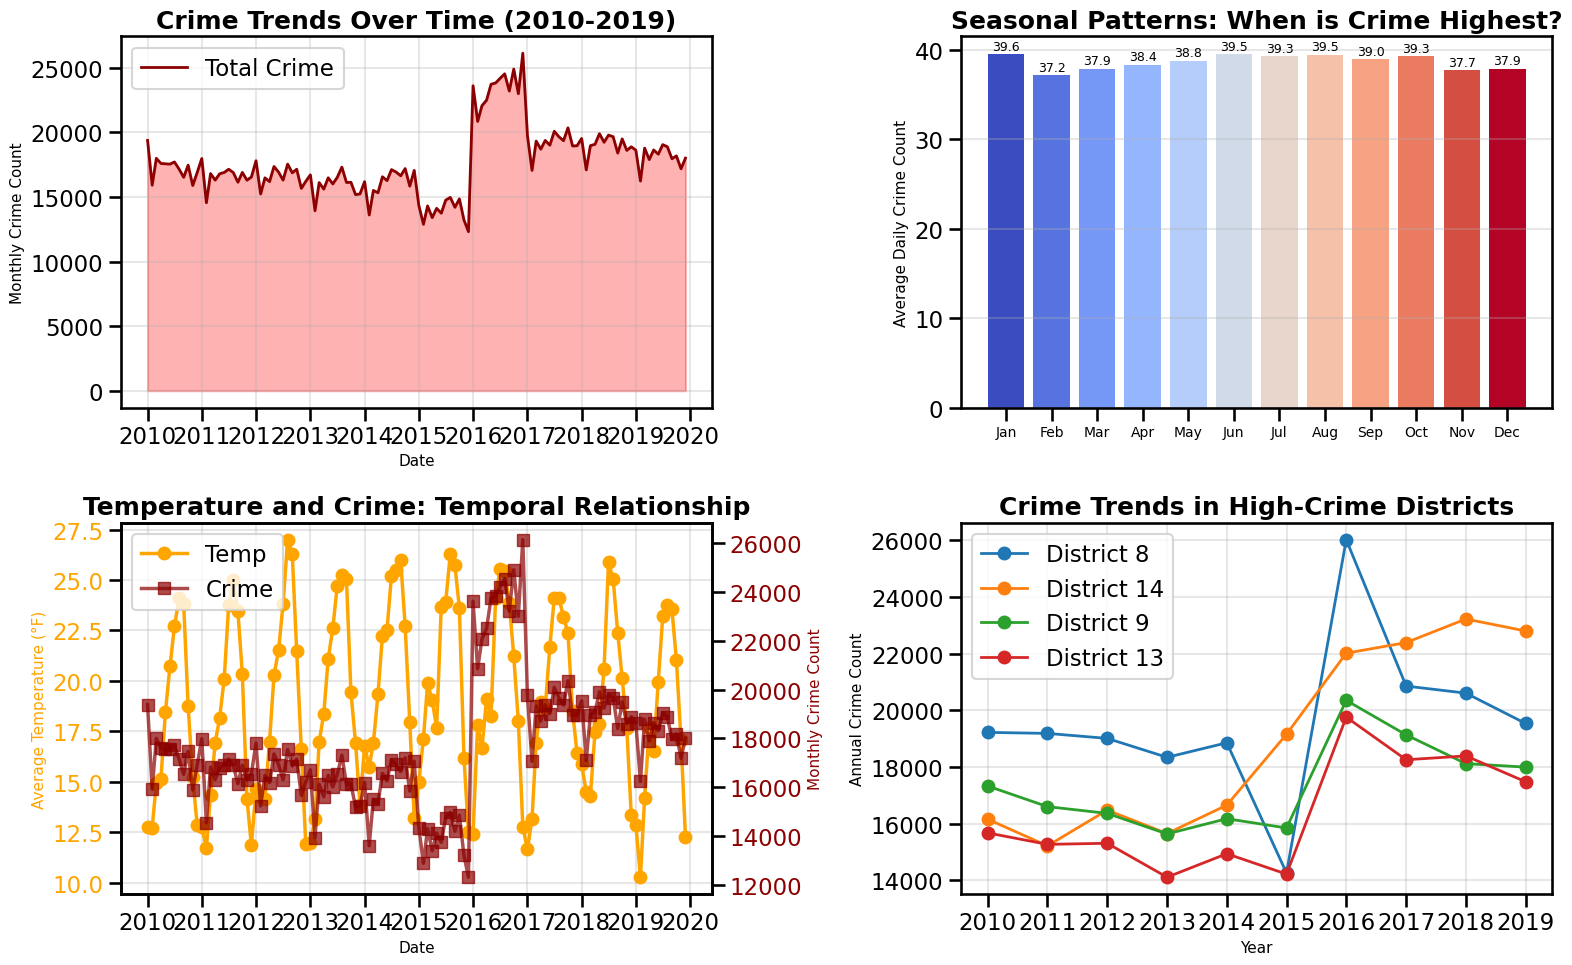

✓ Temporal patterns visualization saved


In [83]:
# Create temporal relationship analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Weather seasonality
monthly_temp = panel_full.groupby(panel_full["date"].dt.to_period("M"))["temperature_mean"].mean()
monthly_temp.index = monthly_temp.index.to_timestamp()
ax1 = axes[0]
ax1b = ax1.twinx()

ax1.plot(monthly_temp.index, monthly_temp.values, linewidth=2.5, color="orange", label="Temp", marker="o")
monthly_crime2 = panel_full.groupby(panel_full["date"].dt.to_period("M"))["crime_count"].sum()
monthly_crime2.index = monthly_crime2.index.to_timestamp()
ax1b.plot(monthly_crime2.index, monthly_crime2.values, linewidth=2.5, color="darkred", label="Crime", marker="s", alpha=0.7)

ax1.set_xlabel("Date", fontsize=11)
ax1.set_ylabel("Average Temperature (°F)", fontsize=11, color="orange")
ax1b.set_ylabel("Monthly Crime Count", fontsize=11, color="darkred")
ax1.tick_params(axis="y", labelcolor="orange")
ax1b.tick_params(axis="y", labelcolor="darkred")
ax1.set_title("Temperature and Crime: Temporal Relationship", fontweight="bold")
ax1.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# 2. District variation over time
district_monthly = panel_full.groupby(["district", panel_full["date"].dt.to_period("Y")])["crime_count"].sum().reset_index()
district_monthly["date"] = district_monthly["date"].dt.to_timestamp()

top_districts = panel_full.groupby("district")["crime_count"].sum().nlargest(5).index
for district in top_districts:
    district_trend = district_monthly[district_monthly["district"] == district]
    axes[1].plot(district_trend["date"], district_trend["crime_count"], 
                 marker="o", linewidth=2, label=f"District {int(district)}")

axes[1].set_xlabel("Year", fontsize=11)
axes[1].set_ylabel("Annual Crime Count", fontsize=11)
axes[1].set_title("Top 5 Highest-Crime Districts Over Time", fontweight="bold")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [84]:

# Create detailed demographic profile with ethnic composition
print("\n" + "=" * 100)
print("DISTRICT ETHNIC/NATIONALITY COMPOSITION BY DISTRICT")
print("=" * 100)

ethnic_cols = ["White_pop", "Black_pop", "Asian_pop", "Hispanic_pop", "Other_pop"]
demo_by_district = socio_clean[["district", "Pop2010"] + ethnic_cols].copy()

# Calculate percentages
for col in ethnic_cols:
    demo_by_district[col + "_pct"] = (demo_by_district[col] / demo_by_district["Pop2010"] * 100).round(1)

# Merge with crime data
crime_by_district = panel_full.groupby("district").agg({
    "crime_count": ["sum", "mean"],
    "renter_share": "first"
}).reset_index()
crime_by_district.columns = ["district", "Total_Crime", "Avg_Daily_Crime", "Renter_Share"]
crime_by_district["Crime_Rate_Per_1000"] = (crime_by_district["Total_Crime"] / 
                                             demo_by_district["Pop2010"].values * 1000).round(1)
crime_by_district["Renter_Share_Pct"] = (crime_by_district["Renter_Share"] * 100).round(1)

# Combine everything
full_profile = demo_by_district.merge(crime_by_district, on="district")

# Create sorted display
display_cols = ["district", "Pop2010", "White_pop_pct", "Black_pop_pct", "Asian_pop_pct", 
                "Hispanic_pop_pct", "Other_pop_pct", "Renter_Share_Pct", "Crime_Rate_Per_1000"]
full_profile_display = full_profile[display_cols].sort_values("Crime_Rate_Per_1000", ascending=False)
full_profile_display.columns = ["District", "Population", "White_%", "Black_%", "Asian_%", 
                                "Hispanic_%", "Other_%", "Renters_%", "Crime_Rate"]

print("\n" + full_profile_display.to_string(index=False))

print("\n\n" + "=" * 100)
print("DEMOGRAPHIC INSIGHTS BY CRIME LEVEL")
print("=" * 100)

# Categorize districts by crime level
median_crime = full_profile["Crime_Rate_Per_1000"].median()
high_crime = full_profile[full_profile["Crime_Rate_Per_1000"] > median_crime]
low_crime = full_profile[full_profile["Crime_Rate_Per_1000"] <= median_crime]

# Calculate correlations with crime rate
demo_crime_corr = pd.DataFrame({
    "Variable": ["White Population %", "Black Population %", "Asian Population %", 
                 "Hispanic Population %", "Other Population %", "Renter Share %"],
    "Correlation_with_Crime": [
        full_profile["White_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        full_profile["Black_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        full_profile["Asian_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        full_profile["Hispanic_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        full_profile["Other_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]),
        (full_profile["Renter_Share"] * 100).corr(full_profile["Crime_Rate_Per_1000"])
    ]
})

demo_crime_corr["Abs_Correlation"] = demo_crime_corr["Correlation_with_Crime"].abs()
demo_crime_corr = demo_crime_corr.sort_values("Abs_Correlation", ascending=False)

print("\nCorrelation Strength (closer to 1.0 = stronger relationship):")
print(demo_crime_corr[["Variable", "Correlation_with_Crime"]].to_string(index=False))




DISTRICT ETHNIC/NATIONALITY COMPOSITION BY DISTRICT

Empty DataFrame
Columns: [District, Population, White_%, Black_%, Asian_%, Hispanic_%, Other_%, Renters_%, Crime_Rate]
Index: []


DEMOGRAPHIC INSIGHTS BY CRIME LEVEL

Correlation Strength (closer to 1.0 = stronger relationship):
             Variable  Correlation_with_Crime
   White Population %                     NaN
   Black Population %                     NaN
   Asian Population %                     NaN
Hispanic Population %                     NaN
   Other Population %                     NaN
       Renter Share %                     NaN


### Demographic and renter relationship visuals — separated graphs

In [ ]:
viz_data = full_profile.sort_values("Crime_Rate_Per_1000", ascending=False).reset_index(drop=True)

renter_share_pct = (full_profile["Renter_Share"] * 100).values
crime_rate = full_profile["Crime_Rate_Per_1000"].values
pop_size = full_profile["Pop2010"].values / 1000

dominant = []
for idx, row in full_profile.iterrows():
    ethic_vals = [row["White_pop_pct"], row["Black_pop_pct"], row["Asian_pop_pct"],
                  row["Hispanic_pop_pct"], row["Other_pop_pct"]]
    labels_list = ["White", "Black", "Asian", "Hispanic", "Other"]
    dominant.append(labels_list[np.argmax(ethic_vals)])

color_map_dict = {"White": "#FF6B6B", "Black": "#4ECDC4", "Asian": "#45B7D1",
                  "Hispanic": "#FFA07A", "Other": "#98D8C8"}
colors_scatter = [color_map_dict[d] for d in dominant]

plt.figure(figsize=(8, 6))
plt.scatter(renter_share_pct, crime_rate, s=pop_size * 2, alpha=0.6, c=colors_scatter,
            edgecolors="black", linewidth=1.5)

for idx, row in full_profile.iterrows():
    plt.annotate(f"D{int(row['district'])}",
                 (renter_share_pct[idx], crime_rate[idx]),
                 fontsize=9, ha="center", va="center", fontweight="bold")

plt.xlabel("Renter Share (%)", fontweight="bold")
plt.ylabel("Crime Rate (per 1000)", fontweight="bold")
plt.title("Crime vs Renter Share (bubble size = population)", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.axhline(crime_rate.mean(), color="red", linestyle="--", alpha=0.5, label="Avg Crime Rate")
plt.axvline(renter_share_pct.mean(), color="blue", linestyle="--", alpha=0.5, label="Avg Renter %")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
hispanic_pop = full_profile["Hispanic_pop_pct"].values
crime_rate = full_profile["Crime_Rate_Per_1000"].values

plt.figure(figsize=(8, 6))
scatter2 = plt.scatter(hispanic_pop, crime_rate, s=150, alpha=0.6,
                       c=crime_rate, cmap="RdYlGn_r", edgecolors="black", linewidth=1.5)

for idx, row in full_profile.iterrows():
    plt.annotate(f"D{int(row['district'])}",
                 (hispanic_pop[idx], crime_rate[idx]),
                 fontsize=9, ha="center", va="center", fontweight="bold")

plt.xlabel("Hispanic Population %", fontweight="bold")
plt.ylabel("Crime Rate (per 1000)", fontweight="bold")
plt.title("Hispanic Population Correlation with Crime", fontweight="bold")
plt.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2)
cbar2.set_label("Crime Rate", fontweight="bold")

z = np.polyfit(hispanic_pop, crime_rate, 1)
p = np.poly1d(z)
x_trend = np.linspace(hispanic_pop.min(), hispanic_pop.max(), 100)
plt.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2,
         label=f'Trend (r={full_profile["Hispanic_pop_pct"].corr(full_profile["Crime_Rate_Per_1000"]):.3f})')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
high_crime_avg = high_crime[["White_pop_pct", "Black_pop_pct", "Asian_pop_pct", "Hispanic_pop_pct"]].mean().values
low_crime_avg = low_crime[["White_pop_pct", "Black_pop_pct", "Asian_pop_pct", "Hispanic_pop_pct"]].mean().values

eth_labels = ["White", "Black", "Asian", "Hispanic"]
x_pos = np.arange(len(eth_labels))
width = 0.35

plt.figure(figsize=(9, 6))
bars1 = plt.bar(x_pos - width/2, high_crime_avg, width, label="High Crime Districts",
                color="#FF6B6B", alpha=0.8, edgecolor="black", linewidth=1.5)
bars2 = plt.bar(x_pos + width/2, low_crime_avg, width, label="Low Crime Districts",
                color="#4ECDC4", alpha=0.8, edgecolor="black", linewidth=1.5)

plt.xlabel("Ethnicity/Nationality", fontweight="bold")
plt.ylabel("Average Population %", fontweight="bold")
plt.title("Demographics: High Crime vs Low Crime Districts", fontweight="bold")
plt.xticks(x_pos, eth_labels)
plt.legend()
plt.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f"{height:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

> Population composition by district remains in the supplementary visuals section.

## 9. Supplementary trend and composition visuals

Moved here to keep the main analysis flow cleaner while preserving all rendered figures.

In [ ]:
plt.figure(figsize=(14, 5))
panel_full.groupby("date")["crime_count"].sum().plot()
plt.title("Total daily crime count across all districts")
plt.xlabel("Date")
plt.ylabel("Crime count")
plt.tight_layout()
plt.show()

In [ ]:
monthly_crime = panel_full.groupby(panel_full["date"].dt.to_period("M"))["crime_count"].sum()
monthly_crime.index = monthly_crime.index.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly_crime.index, monthly_crime.values, linewidth=2, color="darkred", label="Total Crime")
plt.fill_between(monthly_crime.index, monthly_crime.values, alpha=0.3, color="red")
plt.title("Crime Trends Over Time (2010-2019)")
plt.xlabel("Date")
plt.ylabel("Monthly Crime Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
panel_full["month_name"] = pd.to_datetime(panel_full["date"]).dt.strftime("%B")
month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]
seasonal_crime = panel_full.groupby("month_name")["crime_count"].mean().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.bar(range(12), seasonal_crime.values, color=plt.cm.coolwarm(np.linspace(0, 1, 12)))
plt.xticks(range(12), [m[:3] for m in month_order], fontsize=10)
plt.ylabel("Average Daily Crime Count")
plt.title("Seasonal Patterns: When is Crime Highest?")
plt.grid(alpha=0.3, axis="y")
for i, v in enumerate(seasonal_crime.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
panel_sample = panel_full.sample(min(3000, len(panel_full)), random_state=42).copy()
panel_sample["day_type"] = panel_sample["is_weekend"].map({1: "Weekend", 0: "Weekday"})

plt.figure(figsize=(8, 5))
sns.violinplot(data=panel_sample, x="day_type", y="crime_count", palette="Set2")
plt.xlabel("Day Type")
plt.ylabel("Daily Crime Count")
plt.title("Crime Distribution: Weekend vs Weekday")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
viz_data = full_profile.sort_values("Crime_Rate_Per_1000", ascending=False).reset_index(drop=True)

plt.figure(figsize=(16, 6))
ethnic_pcts = viz_data[["White_pop_pct", "Black_pop_pct", "Asian_pop_pct", "Hispanic_pop_pct", "Other_pop_pct"]].values
districts = viz_data["district"].astype(int).values
crime_rates = viz_data["Crime_Rate_Per_1000"].values

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
labels = ['White', 'Black', 'Asian', 'Hispanic', 'Other']

x = np.arange(len(districts))
width = 0.8
bottom = np.zeros(len(districts))

for pct, label, color in zip(ethnic_pcts.T, labels, colors):
    plt.bar(x, pct, width, label=label, bottom=bottom, color=color, alpha=0.8)
    bottom += pct

for i, cr in enumerate(crime_rates):
    intensity = (cr - crime_rates.min()) / (crime_rates.max() - crime_rates.min())
    plt.axvspan(i - 0.4, i + 0.4, alpha=0.05, color='red' if intensity > 0.5 else 'green')

plt.xlabel("District (sorted by crime rate ↓)", fontweight='bold')
plt.ylabel("Population %", fontweight='bold')
plt.title("Ethnic/Nationality Composition by District", fontweight='bold')
plt.xticks(x, [str(d) for d in districts], rotation=45)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()